<h1 style="text-align: center;">Electricity Consumption Forecasting</h1>

The goal of this project is to forecast electricity consumption using time series analysis techniques.
In this project, i apply deep learning methods to predict future electricity consumption based on historical usage patterns.

Import Libraries and Load Dataset

In [ ]:
#import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import MinMaxScaler

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM

In [4]:
#load dataset
df = pd.read_csv("household_power_consumption.csv", on_bad_lines='skip')


/tmp/ipykernel_4281/1166138322.py:2: DtypeWarning: Columns (2,3,4,5,6,7) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("household_power_consumption.csv", on_bad_lines='skip')


In [5]:
#df.head()

,Date,Time,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
0,16/12/2006,17:24:00,4.216,0.418,234.84,18.4,0,1,17.0
1,16/12/2006,17:25:00,5.36,0.436,233.63,23,0,1,16.0
2,16/12/2006,17:26:00,5.374,0.498,233.29,23,0,2,17.0
3,16/12/2006,17:27:00,5.388,0.502,233.74,23,0,1,17.0
4,16/12/2006,17:28:00,3.666,0.528,235.68,15.8,0,1,17.0


EDA - Exploratory Data Analysis

In [6]:
df.shape

(1205684, 9)

In [7]:
df.columns

Index(['Date', 'Time', 'Global_active_power', 'Global_reactive_power',
       'Voltage', 'Global_intensity', 'Sub_metering_1', 'Sub_metering_2',
       'Sub_metering_3'],
      dtype='object')

In [10]:
#Merge Date and time
df["Datetime"] = pd.to_datetime(
    df["Date"] + " " + df["Time"],
    dayfirst=True,
    errors="coerce"
)



In [11]:
df.head()

,Date,Time,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3,Datetime
0,16/12/2006,17:24:00,4.216,0.418,234.84,18.4,0,1,17.0,2006-12-16 17:24:00
1,16/12/2006,17:25:00,5.36,0.436,233.63,23,0,1,16.0,2006-12-16 17:25:00
2,16/12/2006,17:26:00,5.374,0.498,233.29,23,0,2,17.0,2006-12-16 17:26:00
3,16/12/2006,17:27:00,5.388,0.502,233.74,23,0,1,17.0,2006-12-16 17:27:00
4,16/12/2006,17:28:00,3.666,0.528,235.68,15.8,0,1,17.0,2006-12-16 17:28:00


In [12]:
df["Datetime"].isnull().sum()

np.int64(15)

In [13]:
df.dropna(subset=["Datetime"], inplace=True)

In [14]:
df.set_index("Datetime", inplace=True)
df.head()

,Date,Time,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
Datetime,,,,,,,,,
2006-12-16 17:24:00,16/12/2006,17:24:00,4.216,0.418,234.84,18.4,0,1,17.0
2006-12-16 17:25:00,16/12/2006,17:25:00,5.36,0.436,233.63,23,0,1,16.0
2006-12-16 17:26:00,16/12/2006,17:26:00,5.374,0.498,233.29,23,0,2,17.0
2006-12-16 17:27:00,16/12/2006,17:27:00,5.388,0.502,233.74,23,0,1,17.0
2006-12-16 17:28:00,16/12/2006,17:28:00,3.666,0.528,235.68,15.8,0,1,17.0


In [15]:
#select target variable

data = df[["Global_active_power"]]
data.head()

,Global_active_power
Datetime,
2006-12-16 17:24:00,4.216
2006-12-16 17:25:00,5.36
2006-12-16 17:26:00,5.374
2006-12-16 17:27:00,5.388
2006-12-16 17:28:00,3.666


In [16]:
#convert target variable to numeric

data["Global_active_power"] = pd.to_numeric(
    data["Global_active_power"],
    errors="coerce"
)

data.isnull().sum()

/tmp/ipykernel_4281/2679730436.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data["Global_active_power"] = pd.to_numeric(


,0
Global_active_power,7870


In [17]:
#drop missing values

data.dropna(inplace=True)
data.shape

/tmp/ipykernel_4281/3582042381.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data.dropna(inplace=True)


(1197799, 1)

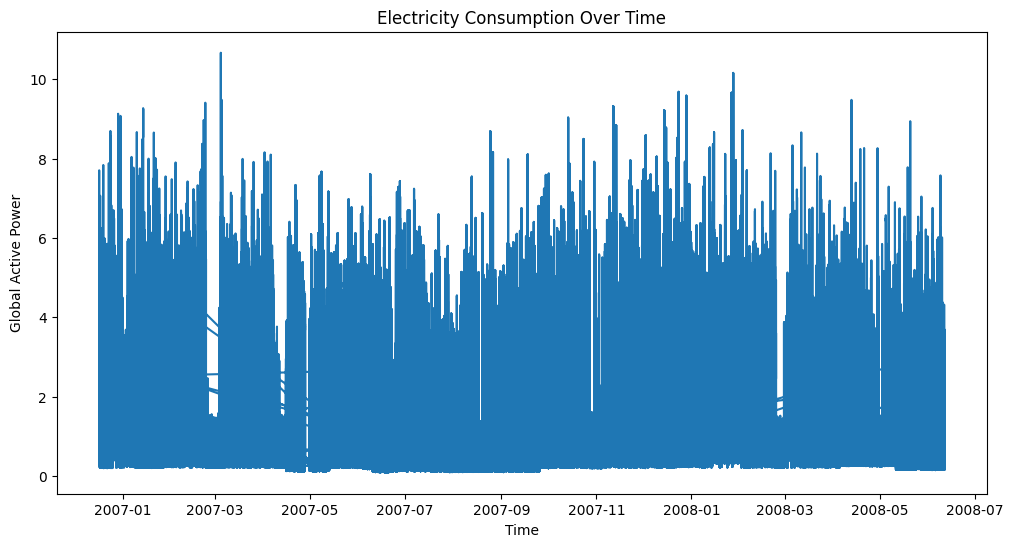

In [18]:
#Plot time series

plt.figure(figsize=(12,6))
plt.plot(data["Global_active_power"])
plt.title("Electricity Consumption Over Time")
plt.xlabel("Time")
plt.ylabel("Global Active Power")
plt.show()

Preprocessing

In [19]:
#scale time series data using MinMaxScaler

scaler = MinMaxScaler(feature_range=(0,1))
scaled_data = scaler.fit_transform(data)

scaled_data[:5]

array([[0.39044201],
       [0.49848886],
       [0.49981111],
       [0.50113336],
       [0.33849641]])

In [20]:
#train test split chronologically

train_size = int(len(scaled_data) * 0.8)

train_data = scaled_data[:train_size]
test_data = scaled_data[train_size:]

print("Train size:", len(train_data))
print("Test size:", len(test_data))

Train size: 958239
Test size: 239560


In [21]:
#create sequences for LSTM

def create_sequences(data, time_step=60):
    X, y = [], []

    for i in range(time_step, len(data)):
        X.append(data[i-time_step:i, 0])
        y.append(data[i, 0])

    return np.array(X), np.array(y)

time_step = 60

X_train, y_train = create_sequences(train_data, time_step)
X_test, y_test = create_sequences(test_data, time_step)

print(X_train.shape, y_train.shape)
print(X_test.shape, y_test.shape)

(958179, 60) (958179,)
(239500, 60) (239500,)


In [22]:
#reshape data for LSTM input

X_train = X_train.reshape(X_train.shape[0], X_train.shape[1], 1)
X_test = X_test.reshape(X_test.shape[0], X_test.shape[1], 1)

print(X_train.shape)
print(X_test.shape)

(958179, 60, 1)
(239500, 60, 1)


Modeling

In [23]:
#build LSTM model

model = Sequential()

model.add(LSTM(50, return_sequences=True, input_shape=(60,1)))
model.add(LSTM(50))
model.add(Dense(1))

model.compile(optimizer="adam", loss="mean_squared_error")

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 60, 50)         │        10,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 50)             │        20,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 30,651 (119.73 KB)

 Trainable params: 30,651 (119.73 KB)

 Non-trainable params: 0 (0.00 B)

In [24]:
#train LSTM model

history = model.fit(
    X_train,
    y_train,
    validation_data=(X_test, y_test),
    epochs=10,
    batch_size=32
)

Epoch 1/10
29944/29944 ━━━━━━━━━━━━━━━━━━━━ 290s 10ms/step - loss: 7.7067e-04 - val_loss: 7.9327e-04
Epoch 2/10
29944/29944 ━━━━━━━━━━━━━━━━━━━━ 283s 9ms/step - loss: 7.3043e-04 - val_loss: 7.2960e-04
Epoch 3/10
29944/29944 ━━━━━━━━━━━━━━━━━━━━ 284s 9ms/step - loss: 7.0565e-04 - val_loss: 6.9953e-04
Epoch 4/10
29944/29944 ━━━━━━━━━━━━━━━━━━━━ 289s 10ms/step - loss: 6.6360e-04 - val_loss: 6.9349e-04
Epoch 5/10
29944/29944 ━━━━━━━━━━━━━━━━━━━━ 286s 10ms/step - loss: 6.4171e-04 - val_loss: 6.6667e-04
Epoch 6/10
29944/29944 ━━━━━━━━━━━━━━━━━━━━ 320s 9ms/step - loss: 6.2712e-04 - val_loss: 6.5548e-04
Epoch 7/10
29944/29944 ━━━━━━━━━━━━━━━━━━━━ 284s 9ms/step - loss: 6.1275e-04 - val_loss: 6.4425e-04
Epoch 8/10
29944/29944 ━━━━━━━━━━━━━━━━━━━━ 288s 10ms/step - loss: 6.0004e-04 - val_loss: 6.3501e-04
Epoch 9/10
29944/29944 ━━━━━━━━━━━━━━━━━━━━ 285s 10ms/step - loss: 5.9004e-04 - val_loss: 6.3642e-04
Epoch 10/10
29944/29944 ━━━━━━━━━━━━━━━━━━━━ 285s 10ms/step - loss: 5.8200e-04 - val_loss: 6.25

In [25]:
#predictions

train_predict = model.predict(X_train)
test_predict = model.predict(X_test)

29944/29944 ━━━━━━━━━━━━━━━━━━━━ 97s 3ms/step
7485/7485 ━━━━━━━━━━━━━━━━━━━━ 24s 3ms/step


In [26]:
#inverse transform predictions

train_predict = scaler.inverse_transform(train_predict)
test_predict = scaler.inverse_transform(test_predict)

y_train_actual = scaler.inverse_transform(y_train.reshape(-1,1))
y_test_actual = scaler.inverse_transform(y_test.reshape(-1,1))

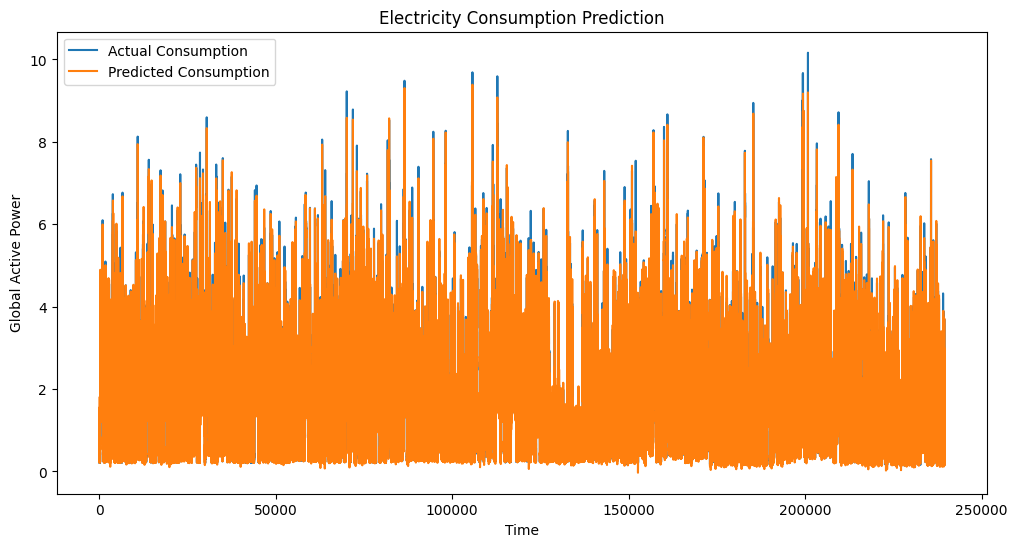

In [27]:
#plot actual vs predicted values

plt.figure(figsize=(12,6))

plt.plot(y_test_actual, label="Actual Consumption")
plt.plot(test_predict, label="Predicted Consumption")

plt.title("Electricity Consumption Prediction")
plt.xlabel("Time")
plt.ylabel("Global Active Power")
plt.legend()

plt.show()

Conclusion: This project demonstrates how LSTM models can be applied to time series forecasting for electricity consumption.

The model successfully captured overall consumption patterns despite the high variability and noise present in household electricity usage data. While short-term fluctuations remain difficult to predict perfectly, the LSTM model learned meaningful temporal dependencies and generated realistic forecasts.

This project highlights the importance of preprocessing, scaling, and sequence modeling when working with real-world time series datasets.

Saving

In [28]:
#save trained LSTM model

model.save("electricity_lstm_model.keras")

In [29]:
#save fitted scaler

import pickle

with open("scaler.pkl", "wb") as f:
    pickle.dump(scaler, f)